[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatiasMaravi/D3Bridge/blob/main/examples/case1.ipynb)

In [ ]:
#%pip install D3Bridge --quiet

In [ ]:
# Cell 1: Train models with MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Define model with layers fc1, fc2, fc3, fc4
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x, return_features=False):
        x = x.view(-1, 28*28)
        
        fc1_out = self.relu(self.fc1(x))
        fc1_out = self.dropout(fc1_out)
        
        fc2_out = self.relu(self.fc2(fc1_out))
        fc2_out = self.dropout(fc2_out)
        
        fc3_out = self.relu(self.fc3(fc2_out))
        fc3_out = self.dropout(fc3_out)
        
        fc4_out = self.fc4(fc3_out)
        
        if return_features:
            return fc4_out, {'fc1': fc1_out, 'fc2': fc2_out, 'fc3': fc3_out, 'fc4': fc4_out}
        return fc4_out

model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model created and ready to train")

Usando dispositivo: cpu
Modelo creado y listo para entrenar


In [ ]:
# Cell 2: Train and extract weights/activations
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}, Loss: {loss.item():.6f}')
    return total_loss / len(train_loader)

def extract_features(model, data_loader, device, max_samples=100):
    """Extract features from model layers"""
    model.eval()
    all_features = {'fc1': [], 'fc2': [], 'fc3': [], 'fc4': []}
    all_labels = []
    
    with torch.no_grad():
        sample_count = 0
        for data, target in data_loader:
            if sample_count >= max_samples:
                break
                
            data, target = data.to(device), target.to(device)
            _, features = model(data, return_features=True)
            
            # Convert to numpy and append to lists
            for layer_name in all_features.keys():
                all_features[layer_name].append(features[layer_name].cpu().numpy())
            all_labels.append(target.cpu().numpy())
            
            sample_count += len(data)
    
    # Concatenate all batches
    for layer_name in all_features.keys():
        all_features[layer_name] = np.concatenate(all_features[layer_name], axis=0)[:max_samples]
    all_labels = np.concatenate(all_labels, axis=0)[:max_samples]
    
    return all_features, all_labels

# Train for multiple epochs
num_epochs = 5
epoch_features = {}
epoch_labels = {}

print("Starting training...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    # Train one epoch
    avg_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Average loss epoch {epoch}: {avg_loss:.4f}")
    
    # Extract features after each epoch
    features, labels = extract_features(model, test_loader, device, max_samples=100)
    epoch_features[epoch] = features
    epoch_labels[epoch] = labels
    
print("\nTraining completed!")
print(f"Features extracted for {len(epoch_features)} epochs")
print(f"Feature shape per layer: {[(k, v.shape) for k, v in epoch_features[0].items()]}")
print(f"Labels: {epoch_labels[0].shape}")

Iniciando entrenamiento...

Época 1/5
Batch 0, Loss: 2.306886
Batch 100, Loss: 0.411098
Batch 200, Loss: 0.217535
Batch 300, Loss: 0.229241
Batch 400, Loss: 0.202188
Batch 500, Loss: 0.191429
Batch 600, Loss: 0.219492
Batch 700, Loss: 0.090827
Batch 800, Loss: 0.181488
Batch 900, Loss: 0.102579
Loss promedio época 0: 0.2710

Época 2/5
Batch 0, Loss: 0.205231
Batch 100, Loss: 0.147150
Batch 200, Loss: 0.197788
Batch 300, Loss: 0.170326
Batch 400, Loss: 0.053012
Batch 500, Loss: 0.110267
Batch 600, Loss: 0.140486
Batch 700, Loss: 0.018072
Batch 800, Loss: 0.119144
Batch 900, Loss: 0.043592
Loss promedio época 1: 0.1267

Época 3/5
Batch 0, Loss: 0.073358
Batch 100, Loss: 0.299086
Batch 200, Loss: 0.028223
Batch 300, Loss: 0.102954
Batch 400, Loss: 0.042288
Batch 500, Loss: 0.159955
Batch 600, Loss: 0.105155
Batch 700, Loss: 0.085310
Batch 800, Loss: 0.032211
Batch 900, Loss: 0.180440
Loss promedio época 2: 0.0982

Época 4/5
Batch 0, Loss: 0.104546
Batch 100, Loss: 0.019891
Batch 200, Loss

Aplicando t-SNE a las características...

Procesando época 0...
  Aplicando t-SNE a capa fc1
Aplicando t-SNE con forma de entrada: (100, 512)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.000s...
[t-SNE] Computed neighbors for 100 samples in 1.643s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 12.377447
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.480663
[t-SNE] KL divergence after 1000 iterations: 0.187749
  Aplicando t-SNE a capa fc2
Aplicando t-SNE con forma de entrada: (100, 256)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.000s...
[t-SNE] Computed neighbors for 100 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 13.095648
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.201706
[t-SNE] KL divergence after 1000 iterations: 0.116383
  Aplicando t-SNE a capa fc3
Aplicando t-SNE con f

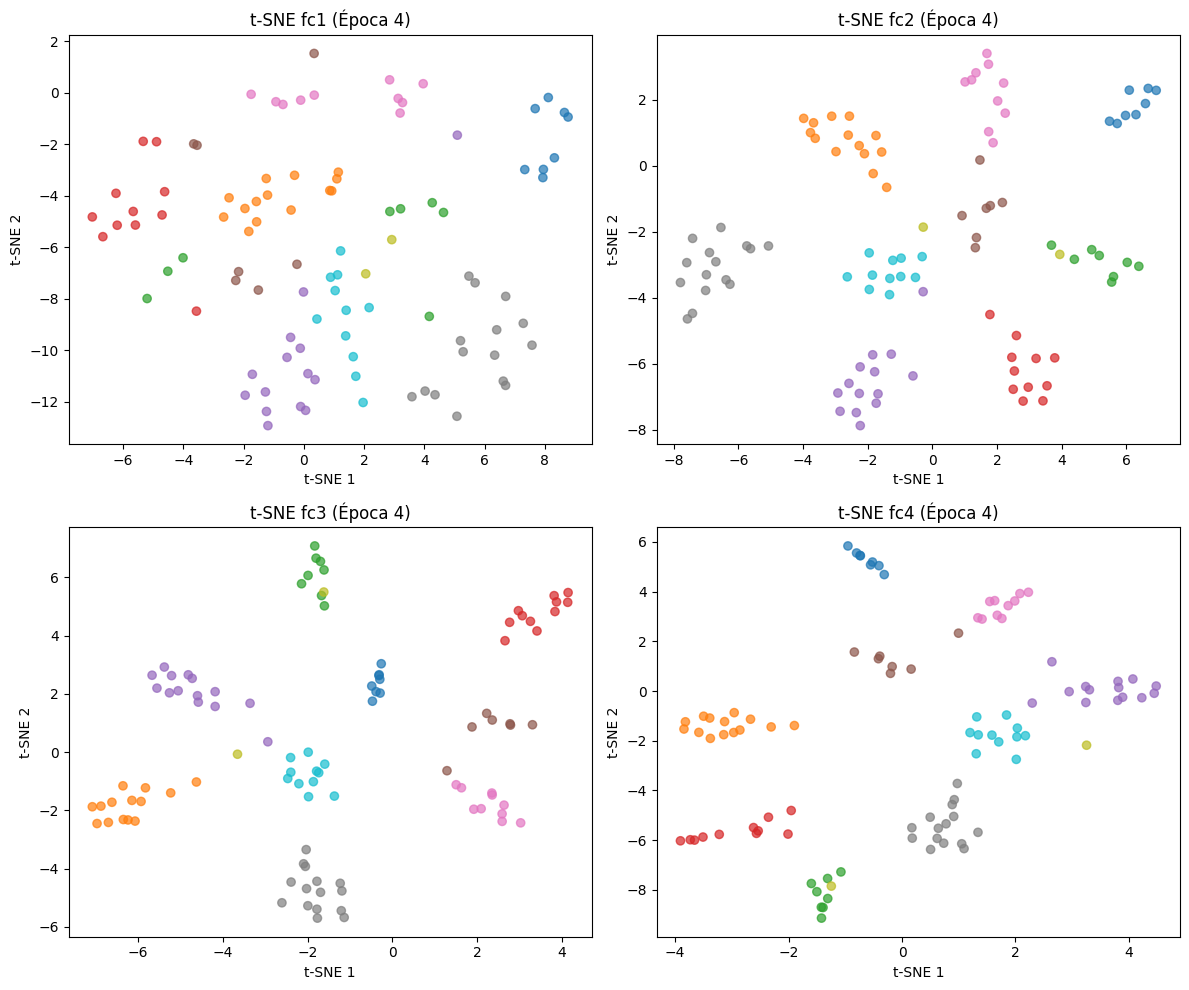

Resultados de t-SNE listos para generar JSONs


In [ ]:
# Cell 3: Apply t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def apply_tsne(features, labels, perplexity=30, max_iter=1000, random_state=42):
    """Apply t-SNE to features"""
    print(f"Applying t-SNE with input shape: {features.shape}")
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=max_iter, random_state=random_state, verbose=1)
    embedded = tsne.fit_transform(features)
    
    return embedded

# Apply t-SNE for each epoch and layer
tsne_results = {}
print("Applying t-SNE to features...")

# For each epoch
for epoch in range(num_epochs):
    tsne_results[epoch] = {}
    print(f"\nProcessing epoch {epoch}...")
    
    # For each layer
    for layer_name in ['fc1', 'fc2', 'fc3', 'fc4']:
        print(f"  Applying t-SNE to layer {layer_name}")
        features = epoch_features[epoch][layer_name]
        labels = epoch_labels[epoch]
        
        # Apply t-SNE
        embedded = apply_tsne(features, labels)
        
        tsne_results[epoch][layer_name] = {
            'embedded': embedded,
            'labels': labels
        }

print("\nt-SNE completed for all epochs and layers!")

# Visualize some results as an example
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, layer_name in enumerate(['fc1', 'fc2', 'fc3', 'fc4']):
    # Use the last epoch for visualization
    last_epoch = num_epochs - 1
    embedded = tsne_results[last_epoch][layer_name]['embedded']
    labels = tsne_results[last_epoch][layer_name]['labels']
    
    scatter = axes[i].scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap='tab10', alpha=0.7)
    axes[i].set_title(f't-SNE {layer_name} (Epoch {last_epoch})')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

print("t-SNE results ready to generate JSONs")

In [ ]:
# Cell 4: Assemble JSONs in the correct format
import json

def create_epoch_by_epoch_json(tsne_results, layer_name="fc4"):
    """Create JSON in epoch_by_epoch format"""
    epoch_data = {
        "layer": layer_name,
        "epochs": []
    }

    for epoch in range(num_epochs):
        epoch_points = []
        embedded = tsne_results[epoch][layer_name]['embedded']
        labels = tsne_results[epoch][layer_name]['labels']

        for i in range(len(embedded)):
            point = {
                "id": i,
                "x": float(embedded[i, 0]),
                "y": float(embedded[i, 1]),
                "label": int(labels[i])
            }
            epoch_points.append(point)

        epoch_info = {
            "epoch": epoch,
            "points": epoch_points
        }
        epoch_data["epochs"].append(epoch_info)

    return epoch_data

def create_layer_by_layer_json(tsne_results, target_epoch=4):
    """Create JSON in layer_by_layer format"""
    # Use the last available epoch if target_epoch does not exist
    actual_epoch = min(target_epoch, num_epochs - 1)

    layer_data = {
        "epoch": actual_epoch,
        "layers": {}
    }

    for layer_name in ['fc1', 'fc2', 'fc3', 'fc4']:
        layer_points = []
        embedded = tsne_results[actual_epoch][layer_name]['embedded']
        labels = tsne_results[actual_epoch][layer_name]['labels']

        for i in range(len(embedded)):
            point = {
                "id": i,
                "x": float(embedded[i, 0]),
                "y": float(embedded[i, 1]),
                "label": int(labels[i])
            }
            layer_points.append(point)

        layer_data["layers"][layer_name] = layer_points

    return layer_data

# Generate JSONs
print("Generating JSONs...")

# epoch by epoch JSON for fc4
epoch_data = create_epoch_by_epoch_json(tsne_results, "fc4")

# layer by layer JSON
layer_data = create_layer_by_layer_json(tsne_results)

from pathlib import Path

Path("samples").mkdir(parents=True, exist_ok=True)

with open(Path("samples") / "tsne_epoch_by_epoch_fc4.json", "w") as f:
    json.dump(epoch_data, f, indent=2)

with open(Path("samples") / "tsne_layer_by_layer.json", "w") as f:
    json.dump(layer_data, f, indent=2)

print("JSONs saved successfully!")
print(f"Epoch by epoch: {len(epoch_data['epochs'])} epochs, {len(epoch_data['epochs'][0]['points'])} points per epoch")
print(f"Layer by layer: {len(layer_data['layers'])} layers, {len(layer_data['layers']['fc1'])} points per layer")

# Show structure of the generated data
print("\nepoch_data structure:")
print(f"Keys: {list(epoch_data.keys())}")
print(f"Number of epochs: {len(epoch_data['epochs'])}")
print(f"Point example: {epoch_data['epochs'][0]['points'][0]}")

print("\nlayer_data structure:")
print(f"Epoch: {layer_data['epoch']}")
print(f"Layers: {list(layer_data['layers'].keys())}")
print(f"fc4 point example: {layer_data['layers']['fc4'][0]}")

# Data is ready to use in visualizations
epoch_data, layer_data

Generando JSONs...
JSONs guardados exitosamente!
Epoch by epoch: 5 épocas, 100 puntos por época
Layer by layer: 4 capas, 100 puntos por capa

Estructura del epoch_data:
Keys: ['layer', 'epochs']
Número de épocas: 5
Ejemplo de punto: {'id': 0, 'x': 2.1678214073181152, 'y': 3.9254984855651855, 'label': 7}

Estructura del layer_data:
Época: 4
Capas: ['fc1', 'fc2', 'fc3', 'fc4']
Ejemplo de punto fc4: {'id': 0, 'x': 0.4957669973373413, 'y': -5.074740409851074, 'label': 7}


({'layer': 'fc4',
  'epochs': [{'epoch': 0,
    'points': [{'id': 0,
      'x': 2.1678214073181152,
      'y': 3.9254984855651855,
      'label': 7},
     {'id': 1, 'x': -1.1468889713287354, 'y': 2.338090181350708, 'label': 2},
     {'id': 2, 'x': 0.6984416246414185, 'y': -0.7589899897575378, 'label': 1},
     {'id': 3, 'x': -6.803772449493408, 'y': -0.10541649907827377, 'label': 0},
     {'id': 4, 'x': 4.492951393127441, 'y': -2.934727907180786, 'label': 4},
     {'id': 5, 'x': 0.8622952699661255, 'y': -1.2071590423583984, 'label': 1},
     {'id': 6, 'x': 4.164165019989014, 'y': -3.205836296081543, 'label': 4},
     {'id': 7, 'x': 3.642486095428467, 'y': -0.6816972494125366, 'label': 9},
     {'id': 8, 'x': -3.740440845489502, 'y': -0.14386387169361115, 'label': 5},
     {'id': 9, 'x': 4.543036937713623, 'y': -0.9478787779808044, 'label': 9},
     {'id': 10,
      'x': -7.080467700958252,
      'y': 0.042818546295166016,
      'label': 0},
     {'id': 11, 'x': -4.848268032073975, 'y':

In [ ]:
# Retrieve and show the image of a point by its ID
import matplotlib.pyplot as plt

def show_mnist_image(image_id):
    """Show the MNIST image corresponding to an ID from the test set"""
    img, label = test_dataset[image_id]
    # Denormalize: invert Normalize((0.1307,), (0.3081,))
    img = img * 0.3081 + 0.1307
    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"ID: {image_id}, Label: {label}")
    plt.axis('off')
    plt.show()



In [ ]:
# Cell 6: Create custom widget for visualization by epochs
from D3Bridge import CustomWidget
import traitlets

class CustomEpoch(CustomWidget):
    #_esm = CustomWidget.createWidgetFromLocalFile(paramList=["data"], filePath=r"d3_epoch.js")
    _esm = CustomWidget.createWidgetFromUrl(paramList=["data"], jsUrl=r"https://raw.githubusercontent.com/MatiasMaravi/D3Bridge/main/D3Bridge/samples/d3_epoch.js")

    data = traitlets.Dict({}).tag(sync=True)

# Create widget instance with the generated data
plot1 = CustomEpoch(data=epoch_data)
print("Epochs widget created with MNIST training data")
print(f"Loaded data: {epoch_data['layer']} with {len(epoch_data['epochs'])} epochs")
# Cell 7: Show visualization by epochs
plot1

Widget de épocas creado con datos de entrenamiento MNIST
Datos cargados: fc4 con 5 épocas


In [ ]:
# Cell 7: Show visualization by epochs
plot1

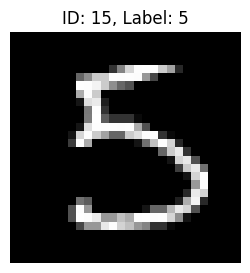

In [ ]:
# Example: show image for point with id=15
show_mnist_image(15)

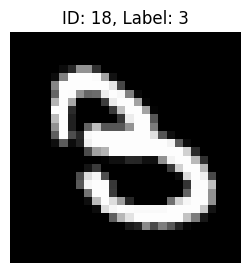

In [ ]:
# Example: show image for point with id=18
show_mnist_image(18)

In [ ]:
# Cell 8: Create and show widget for layer visualization
class CustomLayer(CustomWidget):
    #_esm = CustomWidget.createWidgetFromLocalFile(paramList=["data"], filePath=r"d3_layer.js")
    _esm = CustomWidget.createWidgetFromUrl(paramList=["data"], jsUrl=r"https://raw.githubusercontent.com/MatiasMaravi/D3Bridge/main/D3Bridge/samples/d3_layer.js")

    data = traitlets.Dict({}).tag(sync=True)

# Create widget instance with layer data
plot2 = CustomLayer(data=layer_data)
print("Layers widget created with MNIST training data")
print(f"Loaded data: epoch {layer_data['epoch']} with {len(layer_data['layers'])} layers")
print(f"Available layers: {list(layer_data['layers'].keys())}")

# Show the widget
plot2

Widget de capas creado con datos de entrenamiento MNIST
Datos cargados: época 4 con 4 capas
Capas disponibles: ['fc1', 'fc2', 'fc3', 'fc4']


In [11]:
from D3Bridge import MatrixCreator

m = MatrixCreator(3,4)
m

In [12]:
from D3Bridge import MatrixLayout

l = MatrixLayout(m.data,style="basic")

l.add(plot1,1)
l.add(plot2,2)
l